# Lab 4 — Logistic Regression with Pytorch

In this lab, we will explore **Logistic Regression**, which can be trained using the **Gradient Descent** algorithm.

Specifically, we will cover the following topics:

1. A brief introduction to the **PyTorch** library.  
2. Implementation of a Logistic Regression using PyTorch. 

---

### Materials for the Lab

1. Course slides on Logistic Regression.  
2. PyTorch documentation: [PyTorch Documentation](https://pytorch.org/docs/stable/)  
3. PyTorch tutorials: [PyTorch Tutorials](https://pytorch.org/tutorials/beginner/basics/intro.html)

# Part A. Introduction to PyTorch

**PyTorch** is one of the most widely used libraries for developing deep learning models.  

In this section, we will cover the basic concepts of PyTorch and provide further explanations as we progress through the tutorial.  

For this lab, we will use **PyTorch version 2.14.1**.

In [1]:
# you can install torch by using the following command
!pip install torch==2.14.1


[notice] A new release of pip is available: 23.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# you can install torchsummary by using the following command
# !pip install torchsummary

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [4]:
torch.__version__

'2.14.1'

### Tensors

In PyTorch, we use tensors because they efficiently store data, support GPU acceleration, and enable automatic differentiation for training neural networks.

You can think of tensors as similar to NumPy arrays.

Using tensors, PyTorch can create computational graphs and calculate gradients.

Tensors support various operations, which are listed in the following [link](https://pytorch.org/docs/stable/torch.html#pointwise-ops).  
In addition to the PyTorch operations, we can also apply standard Python operators between tensors.

In [5]:
tensor_1 = torch.tensor([[1., 2.], 
                         [3., 3.]])

tensor_2 = torch.tensor([[1., 0], 
                         [-1., 0]])

In [7]:
print("tensor_1 shape: ", tensor_1.shape)
print("tensor_2 shape: ", tensor_2.shape)

tensor_1 shape:  torch.Size([2, 2])
tensor_2 shape:  torch.Size([2, 2])


In [8]:
elem_mul = tensor_1 * tensor_2
print("Element wise multiplication")
print("Result shape: ", elem_mul.size())
elem_mul

Element wise multiplication
Result shape:  torch.Size([2, 2])


tensor([[ 1.,  0.],
        [-3.,  0.]])

In [9]:
matrix_mul = torch.matmul(tensor_1,tensor_2)
print("Matrix multiplication")
print("Result shape: ", matrix_mul.size())
torch.matmul(tensor_1,tensor_2)

Matrix multiplication
Result shape:  torch.Size([2, 2])


tensor([[-1.,  0.],
        [ 0.,  0.]])

In [10]:
# get tensor as numpy array
tensor_1.data.numpy()

array([[1., 2.],
       [3., 3.]], dtype=float32)

To begin lets define a simple polynomial function.

In [11]:
def f(x):
    """
    A convex function
    f(x) = (x-5)^2
    """
    y = (x-5)**2
    return y

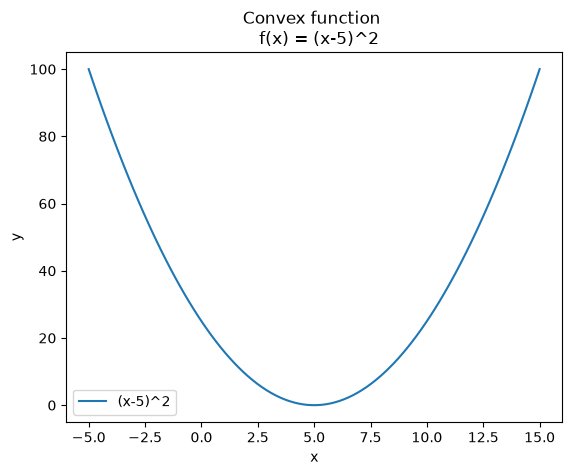

In [12]:
x = torch.linspace(-5, 15, 100)
y = f(x)

plt.figure()
plt.plot(x, y, label = "(x-5)^2")
plt.legend()
plt.title("Convex function \n  f(x) = (x-5)^2")
plt.ylabel("y")
plt.xlabel("x")
plt.show()
plt.close()

# Gradient Descent

**Gradient descent (GD)** is an iterative optimization method used to minimize a differentiable function. For convex functions, any local minimum is also a global minimum.

Gradient descent and its variants are among the most widely used optimization algorithms in machine learning, particularly for training neural networks.

In machine learning, gradient descent minimizes a loss function with respect to the model’s parameters. At each iteration, the parameters are updated in the direction opposite to the gradient, which points toward the steepest local increase in the loss.

<figure>
  <img src="../figures_set2/Gradiend_descent.png" alt="Illustration of gradient descent" width="800"/>
</figure>



The above function has the following computational graph

<p align="center">
  <img style="float: left;" src="../figures_set2/Computational_Graph.png" width="500"/>
</p>

The libraries that implement automatic differentiation keep track of the different operation between variables to construct the computational graph.

Having this graph allows us to compute the gradients of complex function.


Having a computational graph we have two main operation:
1. **Forward pass**: calculate the output of the computational graph. In our example the value of f(x)
2. **Backward pass**: calculate the gradients of each node in the computational graph.
   Having the gradients of each node allows us to calculate the final gradient of each node using the chain rule of differentiation.In our example the df/dx.


<p align="center">
  <img style="float: left;" src="../figures_set2/Auto_diff_Computational_Graph.png" width="900"/>
</p>

In [13]:
# create tensors with requires_grad = true in order to indicate pytorch to track the gradients of the tensor.
x = torch.tensor(1.0, requires_grad = True)

# get the output of a function
y = f(x) # forward pass

# Compute gradients using backward function for y
y.backward()

# Access the gradients using x.grad
gradient = x.grad
print("gradient df(x)/dx|(x=5) :", gradient.data.numpy())

gradient df(x)/dx|(x=5) : -8.0


### Implement Gradient Descent
in the following example we will find the minimum of a function using gradient decent.


<figure>
  <img style="float: left;" src="../figures_set2/sgd.png" width="400"/>
</figure>|

In [14]:
x_init= -13.0
step_max = 500
lr = 0.1

# parameters for stoping
thr = 0.0001

function = f

def gradient_decent(function, x_init, lr, step_max, thr):
    x = torch.tensor(x_init, requires_grad = True)
    
    x_history = [x.data]
    step = 0 
    while step < step_max:
        # step 1. Forward pass to get the output
        y = function(x)

        # step 2. Backward pass to calculate the gradient
        y.backward()

        # step 3. Update x to find minimum
        gradient = x.grad.data
        x.data = x.data - lr * gradient
        x.grad.data.zero_() # technical steps, otherwise accumulate the gradients

        # just keep the values of x
        x_history += [x.data]
        step = step +1
        
        # stopping critiria
        if abs(x.data - x_history[-2]) < thr:
            break
    x_history = np.array(x_history)
    return x.data, step, x_history 

In [24]:
x_min, total_steps, x_history = gradient_decent(function = f, 
                                                x_init = -3.0 ,
                                                lr = 0.5,
                                                step_max = 100,
                                                thr = 0.001)

In [25]:
print("Total steps to achive minimum:" , total_steps)
print("Minimum:" , x_min.data.numpy())

Total steps to achive minimum: 2
Minimum: 5.0


In [26]:
x_history = np.array(x_history)

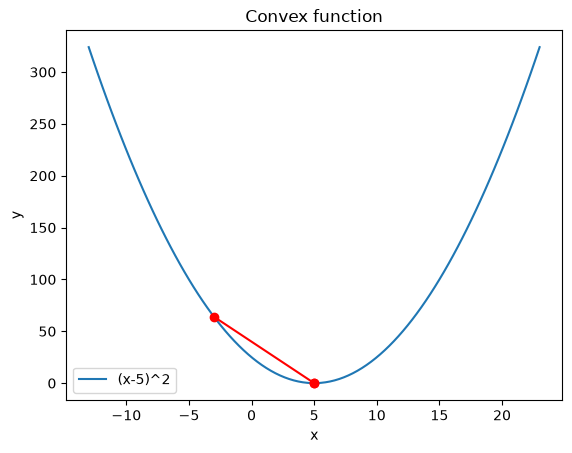

In [27]:
x = np.linspace(-13, 23,100)
# x_history = np.array()
plt.figure()
plt.plot(x, f(x), label = "(x-5)^2")
plt.plot(x_history, f(x_history),marker = "o", color="r")
plt.legend()
plt.title("Convex function")
plt.ylabel("y")
plt.xlabel("x")
plt.show()
plt.close()

### Use an Optimizer

PyTorch makes gradient descent easier to implement with **optimizers**.  
An optimizer updates the model parameters using the gradients computed by `loss.backward()`.  

For example, we can use **Stochastic Gradient Descent (SGD)**:

```python
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [32]:
from torch import nn

x = torch.tensor(x_init, requires_grad = True)
x_parameter = nn.Parameter(x)
optimizer = torch.optim.SGD([x_parameter], lr=0.1) # there are different options for optimizers
x_parameter

Parameter containing:
tensor(-13., requires_grad=True)

In [33]:
optimizer.zero_grad()# reset the gradients
y = function(x_parameter)
y.backward()
optimizer.step()
x_parameter

Parameter containing:
tensor(-9.4000, requires_grad=True)

# Part B. Logistic Regression

In this part, we will implement and train a logistic regression model using **PyTorch**.

### Load data — Breast Cancer Dataset

The Breast Cancer Wisconsin (Diagnostic) dataset contains features computed from digitized images of fine-needle aspirates of breast masses.

It includes 30 numerical features describing characteristics of cell nuclei, such as radius, texture, and smoothness.

The target variable is binary, indicating whether a tumor is **malignant (0)** or **benign (1)**.

In [34]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load data
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# Create DataFrame
data = pd.DataFrame(X, columns=feature_names)

# Add target column
data['target'] = y

In [35]:
data.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### Data Preparation

We start by splitting the data into training, validation, and test sets.   
We then fit a scaler on the training set and use it to transform all three sets, avoiding data leakage.

In [36]:
from sklearn.model_selection import train_test_split

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(data[feature_names], y, test_size=0.2, random_state=42)
X_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,...,10.310,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,...,26.680,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,...,10.010,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,...,12.250,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,11.020,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,...,9.733,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840
106,11.640,18.33,75.17,412.5,0.11420,0.10170,0.07070,0.03485,0.1801,0.06520,...,13.140,29.26,85.51,521.7,0.16880,0.26600,0.28730,0.12180,0.2806,0.09097
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,0.1508,0.05376,...,14.910,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120
435,13.980,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,...,17.040,30.80,113.90,869.3,0.16130,0.35680,0.40690,0.18270,0.3179,0.10550


In [37]:
feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values)
X_test_scaled = scaler.transform(X_test.values)

# Convert back to DataFrames (optional)
train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
train_scaled["target"] = y_train

test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)
test_scaled["target"] = y_test

### Logistic Regression Using scikit-learn

We begin by using scikit-learn’s implementation of logistic regression.   
Next, you will implement your own logistic regression model using PyTorch.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize and train logistic regression
model = LogisticRegression()
model.fit(train_scaled[feature_names], y_train)

# Make predictions
y_pred = model.predict(test_scaled[feature_names])

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9737


# Logistic Regression Using PyTorch

We will now implement logistic regression using **PyTorch**.

Logistic regression is a **linear model for binary classification**: its decision boundary is linear in the input features.

- **Input Layer**: Receives the feature vector $\mathbf{x} = (x_1, x_2, \ldots, x_n)$, where $n$ is the number of features.
- **Labels**: Each training example has a binary label $y \in \{0, 1\}$ indicating its class.

The model estimates the probability that an input belongs to class 1:

$$
\hat{p} = f(x) = \widehat{\Pr}(y=1 \mid \mathbf{x})
= \sigma(\mathbf{w}^{\top}\mathbf{x} + b),
\qquad
\text{where } \sigma(z) = \frac{1}{1 + e^{-z}}.
$$

Here, $\mathbf{w}$ contains the feature weights and $b$ is the bias. The model first computes a linear score called the **logit**:

$$
z = \mathbf{w}^{\top}\mathbf{x} + b.
$$

The **sigmoid function** then converts this logit into a probability between 0 and 1. We use $\hat{p}$ for the predicted probability and $\hat{y}$ for the predicted class.

We obtain a class prediction using a threshold of 0.5:

$$
\hat{y} =
\begin{cases}
1 & \text{if } \hat{p} \geq 0.5,\\
0 & \text{otherwise}.
\end{cases}
$$

To train the model, we minimize the **binary cross-entropy loss** over the $N$ training examples:

$$
\mathcal{L}(\mathbf{w}, b)
=
-\frac{1}{N}\sum_{i=1}^{N}
\left[
y_i \log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right].
$$

During training, PyTorch automatically computes the gradients of the loss with respect to $\mathbf{w}$ and $b$.  
We use these gradients to update the parameters through gradient descent.

In [26]:
import torch
from torch import nn


class MyLogisticRegression:
    def __init__(self, n_features):
        self.n_features = n_features
        self.weights = nn.Parameter(torch.zeros(n_features))
        self.bias = nn.Parameter(torch.zeros(1))

    def predict_proba(self, X):
        X = torch.as_tensor(X, dtype=torch.float32)

        logits = 
        sigmoid = 
        return 

    def predict(self, X, threshold=0.5):
        # Disable gradient tracking during prediction to reduce memory use
        # and avoid unnecessary gradient computations.
        with torch.no_grad():
            probabilities = 
            prediction =
            return prediction

    def fit(self, X, y, lr=0.01, n_iter=1000):
        X = torch.as_tensor(X, dtype=torch.float32)
        y = torch.as_tensor(y, dtype=torch.float32).reshape(-1)

        # Initialise parameters
        self.weights = nn.Parameter(torch.zeros(self.n_features))
        self.bias = nn.Parameter(torch.zeros(1))

        loss_fn = nn.BCELoss()
        optimizer = torch.optim.SGD(
            [self.weights, self.bias], lr=lr
        )

        for _ in range(n_iter):
            # 1. Reset gradients of the optimizer

            # Predict probabilities and calculate loss
            probabilities = 

            # Compute Loss
            loss = loss_fn(probabilities, y)

            # Compute gradients and update parameters
            ...
            ...

        return 

### **Step 1 — Implement `predict_proba`**

In this step, you will implement the `predict_proba` method of the `MyLogisticRegression` class.  
This method should return the **predicted probabilities** that each sample belongs to class `1`.

The logistic regression model predicts probabilities using the **sigmoid function**:

$\hat{y} = Pr(y=1|x) = \sigma(Xw + b) , \quad \text{where } \sigma(z) = \frac{1}{1 + e^{-z}}$

Here:  
- $X$ is the input data matrix, with shape `(n_samples, n_features)`.
- $w$ is the weight vector (learned parameters), with shape `(n_features,1)`.
- $b$ is the bias term, with shape `(1,)`, added to every sample’s score.
- $\sigma$ is the sigmoid function, applied elementwise.

Try it on the data:

In [27]:
model_torch = MyLogisticRegression(n_features = len(feature_names))

In [28]:
predicted_probabilities = model_torch.predict_proba(X_test_scaled)

In [29]:
predicted_probabilities

tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 

### **Step 2 — Implement `predict`**

In this step, you will implement the `predict` method of the `LogisticRegression` class.  
This method should return the **predicted class labels** (`0` or `1`) for each input sample.

The `predict` method relies on the probabilities obtained from your `predict_proba` method.

In [30]:
predictions = model_torch.predict(X_test_scaled)
predictions

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

### **Step 3 — Implement `fit`**

In this step, you will implement the `fit` method of the `MyLogisticRegression` class.

This method trains the model using **full-batch gradient descent**: every parameter update is based on the **entire training set**.

The goal is to find parameters $w$ and $b$ that minimize the **binary cross-entropy loss**:

$$
L(w,b) = -\frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right],
$$

where $n$ is the number of training examples and $\hat{p}_i = \sigma(w^\top x_i + b)$ is the predicted probability of class 1.



### A. Binary Cross-Entropy

Run the code bellow and answer the following questions:

1. When the true label is 1, what happens to the loss as the predicted probability increases?
2. When the true label is 0, what happens to the loss as the predicted probability increases?

In [31]:
loss_fn = nn.BCELoss()
for label in [0.0, 1.0]:
    print(f"\nTrue label: {int(label)}")

    for probability in [0.01, 0.1, 0.5, 0.9, 0.99]:
        prediction = torch.tensor([probability])
        target = torch.tensor([label])

        loss = loss_fn(prediction, target)

        print(
            f"Predicted probability: {probability:.2f} "
            f"→ Loss: {loss.item():.4f}"
        )


True label: 0
Predicted probability: 0.01 → Loss: 0.0101
Predicted probability: 0.10 → Loss: 0.1054
Predicted probability: 0.50 → Loss: 0.6931
Predicted probability: 0.90 → Loss: 2.3026
Predicted probability: 0.99 → Loss: 4.6052

True label: 1
Predicted probability: 0.01 → Loss: 4.6052
Predicted probability: 0.10 → Loss: 2.3026
Predicted probability: 0.50 → Loss: 0.6931
Predicted probability: 0.90 → Loss: 0.1054
Predicted probability: 0.99 → Loss: 0.0101


you can make also a plot with the two lines.

#### **Implementation Steps**

1. **Prepare the data and initialize the parameters**:
   - Convert $X$ and $y$ into PyTorch tensors with type `torch.float32`.

2. **Define the loss function and optimizer**:
   - Use `nn.BCELoss()` to compute the mean binary cross-entropy loss.
   - Use `torch.optim.SGD` to update $w$ and $b$ with learning rate $\alpha$.

3. **For a fixed number of iterations (epochs)**:
   - Reset the previous gradients using `optimizer.zero_grad()`.
   - Compute the predicted probabilities for the entire training set using `predict_proba(X)`.
   - Compute the loss by comparing these probabilities with the true labels.
   - Call `loss.backward()` to compute the gradients automatically.
   - Call `optimizer.step()` to update the parameters:

$$
w \leftarrow w - \alpha \nabla_w L,
\qquad
b \leftarrow b - \alpha \frac{\partial L}{\partial b}.
$$

For reference, the gradients computed by PyTorch correspond to:

$$
\nabla_w L = \frac{1}{n}X^\top(\hat{p}-y),
\qquad
\frac{\partial L}{\partial b}
= \frac{1}{n}\sum_{i=1}^{n}(\hat{p}_i-y_i).
$$

The weight gradient has shape `(n_features,)`, matching $w$.

> **Use vectorized operations:** one loop over epochs is necessary, but avoid loops over individual samples.

#### **Pseudocode**

    Input: Training data X, labels y, learning rate α, number of epochs

    Initialize weights w and bias b to zero
    Define the binary cross-entropy loss
    Create an SGD optimizer for w and b with learning rate α

    For each epoch:
        Reset the gradients
        probabilities ← predict_proba(X)
        loss ← binary_cross_entropy(probabilities, y)
        Compute gradients using loss.backward()
        Update w and b using optimizer.step()

    Return the trained model

Each epoch uses the entire training set and performs one parameter update.

In [32]:
model_torch.fit(X=X_train_scaled, y=y_train, lr=0.01, n_iter=1000)

### Step 4 — Make Predictions on the Test Set

Compute the test accuracy on the test set.

In [33]:
y_pred = 
y_pred

tensor([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
        1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0])

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9825


# Part C. Multiclass Classification

Now, extend your logistic regression implementation from binary classification to **multiclass classification**, where each sample belongs to one of $C$ classes. In this exercise, use the Iris dataset, which has $C=3$ classes.

You will need to make three changes:
- Produce **one score per class** instead of a single score.
- Replace the **sigmoid** function with **softmax**.
- Replace **binary cross-entropy** with **multiclass cross-entropy**.

For each input $x \in \mathbb{R}^d$, the model produces a vector of class scores:

$$
z = Wx + b,
$$

where $W \in \mathbb{R}^{C \times d}$ and $b \in \mathbb{R}^C$.

The **softmax function** converts these scores into class probabilities:

$$
P(y=k \mid x)
=
\frac{\exp(z_k)}{\sum_{j=1}^{C}\exp(z_j)}.
$$

The probabilities sum to $1$. Predict the class with the **highest probability**.

## Your tasks

1. Load the Iris dataset.
2. Define trainable parameters `W` and `b` so your model produces **C outputs** per sample.
3. Replace sigmoid with softmax to compute the class probabilities.
4. Change the loss function to multiclass cross-entropy and train the model.
5. Predict the classes of the test samples and compute the **accuracy**.

**Implementation:** For `X_train` of shape `(N, d)`, define `W` with shape `(d, C)` and `b` with shape `(C,)`. Compute the scores using:

```python
logits = X_train @ W + b
```

The code stores the transpose of the weight matrix used in the mathematical expression above.

**Loss function:** Multiclass cross-entropy penalizes the model when it assigns a low probability to the correct class:

$$
L = -\frac{1}{N}\sum_{i=1}^{N}\log P(y=y_i \mid x_i).
$$

First, use softmax to obtain class probabilities. Then, take their logarithm using `torch.log()` and pass the log-probabilities to `nn.NLLLoss()`:

```python
probabilities = torch.softmax(logits, dim=1)
log_probabilities = torch.log(probabilities)
loss = nn.NLLLoss()(log_probabilities, y_train)
```

Here, `dim=1` applies softmax across the classes for each sample.
The target labels should be integers from `0` to `C - 1`, with dtype `torch.long`.

**Numerical stability:** Once you understand these steps, use
`torch.log_softmax(logits, dim=1)` to compute the log-probabilities directly.

In [41]:
features = ['Sepal_Length', 'Sepal_Width', 'Petal_Length', 'Petal_Width']

target = 'Class'

### load some data with pandas

csv_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
dataset = pd.read_csv(csv_url, names=features + [target])
data_x = dataset[features]
data_y = dataset[[target]]